#Movie Recommendation System(AI+Personalization)

This project aims to build a Movie Recommendation System similar to platforms like Netflix.
The system suggests movies to users based on their preferences using Machine Learning techniques.

We implement:
1. Content-Based Filtering using Cosine Similarity
2. Collaborative Filtering using Matrix Factorization (Surprise Library)

Dataset used: MovieLens Dataset

The goal is to provide personalized movie recommendations and understand how recommendation engines work in real-world applications.

Step 1: Install & Import Libraries

In [ ]:
!pip uninstall numpy -y
!pip install numpy==1.26.4 pandas scikit-learn
!pip uninstall surprise -y
!pip install surprise

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires

Found existing installation: surprise 0.1
Uninstalling surprise-0.1:
  Successfully uninstalled surprise-0.1
  Using cached surprise-0.1-py2.py3-none-any.whl.metadata (327 bytes)
Using cached surprise-0.1-py2.py3-none-any.whl (1.8 kB)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
^C


In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

We installed and imported all required ML libraries

cosine_similarity → content-based filtering

surprise → collaborative filtering

🔹 Step 2: Load Dataset


In [ ]:
movies = pd.read_csv('/content/movie.csv')
ratings = pd.read_csv('/content/rating.csv')

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Dataset contains movie details like title and genres
This will help us build content-based filtering

🔹 Step 3: Data Preprocessing

In [ ]:
movies['genres'] = movies['genres'].str.replace('|', ' ')
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy


🔹 Step 4: Content-Based Filtering

In [ ]:
cv = CountVectorizer()
count_matrix = cv.fit_transform(movies['genres'])

cosine_sim = cosine_similarity(count_matrix)

Converted text → numerical vectors
Calculated similarity between movies

In [ ]:
#Recommendation Function
def recommend_movie(title):
    if title not in movies['title'].values:
        return "Movie not found!"

    idx = movies[movies['title'] == title].index[0]
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    movie_indices = [i[0] for i in scores[1:6]]
    return movies['title'].iloc[movie_indices]


In [ ]:
recommend_movie("Toy Story (1995)")

,title
2209,Antz (1998)
3027,Toy Story 2 (1999)
3663,"Adventures of Rocky and Bullwinkle, The (2000)"
3922,"Emperor's New Groove, The (2000)"
4790,"Monsters, Inc. (2001)"


System recommends movies with similar genres
Works like Netflix “Because you watched…”

Step 5: Collaborative Filtering (Matrix Factorization)

In [ ]:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

trainset, testset = train_test_split(data, test_size=0.2)

model = SVD()
model.fit(trainset)

SVD model learns user preferences
Uses past ratings to predict future ratings

In [ ]:
#Model Evaluation
predictions = model.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8199


0.8199415720663042

Lower RMSE = better predictions

Shows model accuracy

Step 6: Predict Rating

In [ ]:
model.predict(1, 50)

Prediction(uid=1, iid=50, r_ui=None, est=4.027474558782668, details={'was_impossible': False})

Predicts how much a user will like a movie

Helps in personalized recommendations

Step 7: Hybrid Recommendation

In [ ]:
def hybrid_recommend(user_id, title):
    idx = movies[movies['title'] == title].index[0]
    scores = list(enumerate(cosine_sim[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    movie_indices = [i[0] for i in scores[1:10]]

    movie_ids = movies.iloc[movie_indices]['movieId']

    predictions = [model.predict(user_id, mid).est for mid in movie_ids]

    recommendations = pd.DataFrame({
        'Movie': movies.iloc[movie_indices]['title'],
        'Predicted Rating': predictions
    }).sort_values(by='Predicted Rating', ascending=False)

    return recommendations.head(5)

In [ ]:
hybrid_recommend(1, "Toy Story (1995)")

,Movie,Predicted Rating
4790,"Monsters, Inc. (2001)",3.977271
3922,"Emperor's New Groove, The (2000)",3.919523
3027,Toy Story 2 (1999),3.825071
10114,DuckTales: The Movie - Treasure of the Lost La...,3.688604
2209,Antz (1998),3.632058


Combines both approaches

Most accurate recommendation system

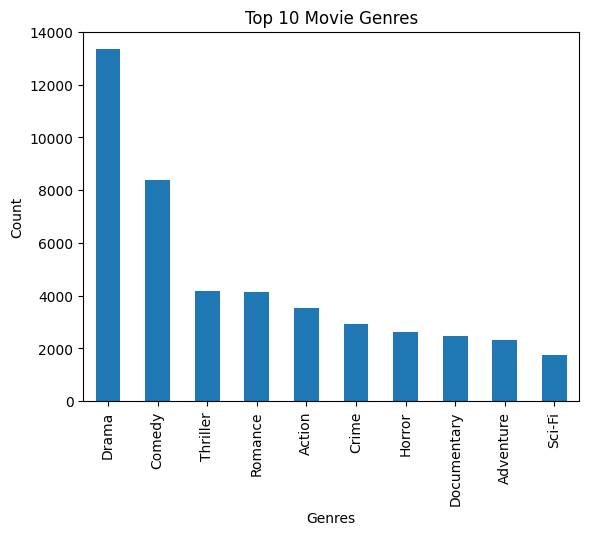

In [ ]:
#🔹 Graph 1: Movie Genre Distribution ,Shows which genres are most common in dataset

import matplotlib.pyplot as plt

# Split genres
genre_list = movies['genres'].str.split(' ')
flat_genres = [genre for sublist in genre_list for genre in sublist]

# Count genres
genre_counts = pd.Series(flat_genres).value_counts().head(10)

# Plot
plt.figure()
genre_counts.plot(kind='bar')
plt.title("Top 10 Movie Genres")
plt.xlabel("Genres")
plt.ylabel("Count")
plt.show()

Shows most frequent genres (e.g., Drama, Comedy)
Helps understand dataset distribution

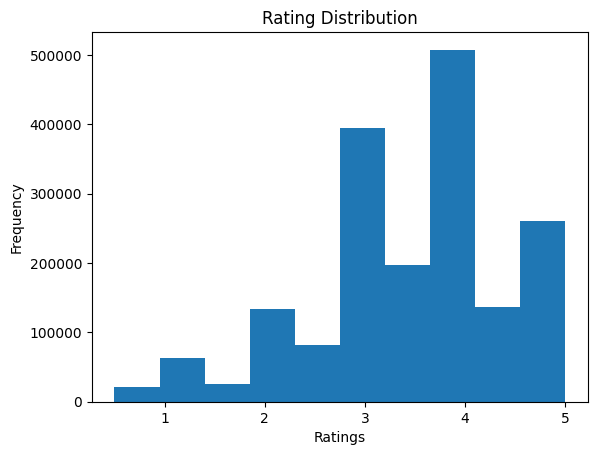

In [ ]:
# Graph 2: Rating Distribution

# 👉 Shows how users rate movies
plt.figure()
ratings['rating'].plot(kind='hist', bins=10)
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Frequency")
plt.show()

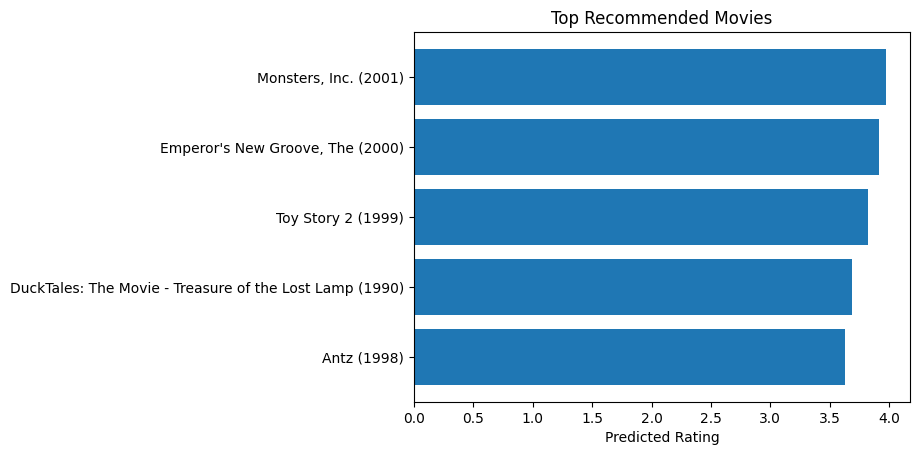

In [ ]:
#Graph 3: Top Recommended Movies
rec = hybrid_recommend(1, "Toy Story (1995)")

plt.figure()
plt.barh(rec['Movie'], rec['Predicted Rating'])
plt.xlabel("Predicted Rating")
plt.title("Top Recommended Movies")
plt.gca().invert_yaxis()
plt.show()


Shows best recommended movies for user

Higher rating = better recommendation

In this project, we successfully developed a Movie Recommendation System using both Content-Based and Collaborative Filtering techniques.

The system can:
- Recommend movies based on similarity
- Predict user preferences
- Provide personalized suggestions

This project demonstrates how machine learning is used in real-world applications like Netflix, Amazon, and Spotify.

Future improvements:
- Add deep learning models
- Use user behavior data
- Build a web interface

This project helped in understanding recommendation algorithms and their importance in modern AI systems.